This notebook is used to process campaign supersaturation/humidity data.

Campaigns from 500k dataset w/ environmental data:  
- ARM: https://www.arm.gov/research/campaigns/sgp2000sprcloud
- CRYSTAL-FACE NASA: https://espoarchive.nasa.gov/archive/browse/crystalf/WB57
- CRYSTAL-FACE UND: https://espoarchive.nasa.gov/archive/browse/crystalf/Citation
- MC3E: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmmc3e-1
- MIDCIX: https://espoarchive.nasa.gov/archive/browse/midcix/WB57
- MPACE: water vapor measurements had issues. 

Other campaigns:
- OLYMPEX: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmolyx-1 (last access: 1/12/26)  
- AIRS_II: https://data.eol.ucar.edu/project/AIRS-II (last access: 1/19/26)
- ATTREX: https://espoarchive.nasa.gov/archive/browse/attrex/id4/GHawk (last access: 1/19/26)
- ESCAPE: https://data.eol.ucar.edu/dataset/list?project=619&children=project (last access: 1/19/26)
- ICE_L: https://data.eol.ucar.edu/master_lists/generated/ice-l/ (last access: 1/19/26)
- IPHEX: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmiphx-1 (last access: 1/19/26)
- ISDAC: https://armgov.svcs.arm.gov/research/campaigns/aaf2008isdac (last access: 1/19/26)
- MACPEX: https://espoarchive.nasa.gov/archive/browse/macpex/WB57 (last access: 1/19/26)
- POSIDON: https://espoarchive.nasa.gov/archive/browse/posidon/WB57 (last access: 1/19/26)

- (1/23/26) Kara Note: Check the ICT metadata of the water vapor instruments for time shift corrections.
- https://amt.copernicus.org/articles/18/5321/2025/
- other potential measurements to use: ice # concentration, 
    - e.g., sparse clouds versus dense clouds -> what are the implications (e.g., well-mixed, age) 
    - aerosol
- general cloud regime label

In [12]:
import pandas as pd
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import polars as pl
import umap
import glob
import re
from pathlib import Path
from typing import Callable, Dict
from datetime import datetime, timedelta
import xarray as xr
from xarray.coding.times import CFDatetimeCoder

# Data description and provenance

Description of in situ atmospheric measurements for different campaigns.

## ARM
- Data source: https://www.arm.gov/research/campaigns/sgp2000sprcloud (last access: 1/13/26)  
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/ARM  (accessed: 1/14/26)
- "Browse Data" link will take you to ARM Data Discovery portal (https://adc.arm.gov/)
- Data Product: Citation A/C
- After logging in, will take you to following data archive: https://iop.arm.gov/2000/sgp/cloud
- Data is in "poellot-citation" directory
- Si/RH is NOT pre-calculated:
    - Use frost point to calculate Si
    - Air Temp available: "Air Temp Rosemount (C)"

## CRYSTAL-FACE-NASA
- Data Source: https://espoarchive.nasa.gov/archive/browse/crystalf/WB57 (last access: 1/14/26)  
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-NASA (last access: 1/14/26)
- Link directs to NASA ESPO Data Archive
- Look for JLH (JPL Laser Hygrometer) data files
- RH relative to ice is provided
- Use Static Temperature (K) from MMS for air temperature (in the JLH files)
    - "T(K)"

## CRYSTAL-FACE-UND
- Data Source: https://espoarchive.nasa.gov/archive/browse/crystalf/Citation (last access: 1/14/26)  
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-UND (1/14/26)
- Link directs to NASA ESPO Data Archive
- Relevant Data Product: ND* files in Poellot section
- RH is calculated and available in *MIS.CIT files
- Air Temp and Frost Point available in *MET.CIT files: "Air_Temp_w"

## MC3E
- Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmmc3e-1 (last access: 1/14/26)  
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/MC3E  (last access: 1/14/26)
- Link directs to NASA Data Catalog page for campaign. 
- "Data Access" > "GET DATA" > filter for *mc3e files in NASA EarthData 
- Si is NOT pre-computed in files. 
    - Calculate Si from frost point
    - Air Temp available: "Air_Temp"

## MidCix
- Data Source: https://espoarchive.nasa.gov/archive/browse/midcix/WB57 (last access: 1/14/26)  
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/MidCix (last access: 1/14/26)
- Link directs to NASA ESPO Data Archive
- Relevant Data Product: JW* files in JLH section
- RH relative to ice is provided
- Use Static Temperature (K) from MMS for air temperature (in the JLH files)
    - "T(K)"

## OLYMPEX
- Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmolyx-1 (last access: 1/14/26)  
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/OLYMPEX (last access: 1/14/26)
- Link directs to NASA Data Catalog page for campaign. 
- "Data Access" > "GET DATA" > filter for *olympex files in NASA EarthData 
- Si is NOT pre-computed in files. 
    - Calculate Si from frost point
    - Air Temp available: "Air_Temp"

## AIRS-II
- Data Source: https://data.eol.ucar.edu/project/AIRS-II (last access: 1/19/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/AIRS-II (last access: 1/19/26)
- Link directs to NCAR EOL Field Data Archive webpage
- Navigate to "Datasets from this project" link > Navigation, State Parameter, and Microphysics Low-Rate (1 sps) Flight-Level Data [NCAR/EOL]
- Need to fill out order data form and instructions for download will be emailed
- Relevant variables:
    - RHUM: relative humidity
    - DPXC: frost point (corrected)
    - ATX: temperature (corrected)
    - PSXC: static pressure (corrected)
    - TDL: raw voltages, no calibration coefficients seem to be present to convert to humidity
    

## ATTREX
- Data Source: https://espoarchive.nasa.gov/archive/browse/attrex/id4/GHawk (last access: 1/19/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/ATTREX (last access: 1/19/26)
- 2 water vapor instruments: NOAA H2O, DLH 
    - UCATS H2O also available, but longer time integrations
- Pressure and Temp in MMS files
- references: 
    - Jensen et al. 2017a (https://doi.org/10.1175/BAMS-D-14-00263.1)
    - Jensen et al. 2017b (https://doi.org/10.1002/2017JD026632)
    - "The agreement between water vapor concentrations measured by NOAA-H2O and DLH during ATTREX was excellent"
- COCPIT CPI date range: 2014-03-04 17:41:32 to 2014-03-05 06:09:23
    - more CPI available on campaign dataset repository

## ESCAPE
- Data Source: https://data.eol.ucar.edu/dataset/list?project=619&children=project (last access: 1/19/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/ESCAPE (last access: 1/19/26)
- Relevant Datasets: 
    - SPEC Learjet Instrument Data (https://data.eol.ucar.edu/dataset/619.003)
    - ESCAPE: Atmospheric and Aircraft State Data (https://data.eol.ucar.edu/dataset/619.015)
- Water vapor concentrations in "Atmospheric and Aircraft State Data" not corrected for in-cloud measurements. Better to use SPEC measurements (probably?).
- CPI taken on Learjet as well so best co-located measurements.

## ICE-L
- Data Source: https://data.eol.ucar.edu/master_lists/generated/ice-l/ (last access: 1/19/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/ICE-L (last access: 1/19/26)
- Dataset: Navigation, State Parameter, and Microphysics Flight-Level Data
- ORDER data and download via link provided via email

## IPHEX
- Data Source: https://www.earthdata.nasa.gov/data/catalog/ghrc-daac-gpmcmiphx-1 (last access: 1/19/26)
- Campaign NASA webpage: https://www.earthdata.nasa.gov/data/projects/iphex (last access: 1/19/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/IPHEX (last access: 1/19/26)
- Download from NASA Earthdata Explorer > filter for *iphex files
- Si not pre-computed:  
    - derive from frost point
    - air temp variable: "Air_Temp"


## ISDAC
- DOE ARM campaign webpage: https://armgov.svcs.arm.gov/research/campaigns/aaf2008isdac (last access: 1/19/26)
- Data Source: https://adc.arm.gov/discovery/#/results/iopShortName::aaf2008isdac (last access: 1/19/26), https://iop.arm.gov/2008/nsa/isdac (last access: 1/21/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/ISDAC (last access: 1/21/26)
- 1/19/26: not sure where the water vapor/RH measurements are...in progress
    - CONVAIR580: Derived PWV, convair
    - microphysics: does not contain any vapor measurements

## MACPEX
- Data Source: https://espoarchive.nasa.gov/archive/browse/macpex/WB57 (last access: 1/21/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/MACPEX (last access: 1/21/26)
- reference: https://doi.org/10.1002/2013JD020817
- UT/LS focused water vapor measurements intercomparison study
    - Harvard Lyman-α Photofragment Fluorescence Hygrometer (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/HWV)
    - Closed-path Laser Hygrometer (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/CLH-Enhanced)
    - Diode Laser Hygrometer (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/DLH-H2O)
    - JPL Laser Hygrometer (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/JLH)
    - Unmanned Aerial System Laser Hygrometer (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/ULH)
    - Fast In-situ Stratospheric Hygrometer (FISH) (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/FISH-H2Otot) > TOTAL WATER > "Because FISH measured total water, the FISH data are included only when the RHi as calculated from the FISH data was less than 90%." > NOT DOWNLOADED
    - NOAA Chemical Ionization Mass Spectrometer, CIMS (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/CIMS-H2O)
- Met data (https://espoarchive.nasa.gov/archive/browse/macpex/WB57/MMS-MetData), which includes temperature and pressure
     

## POSIDON
- Data Source: https://espoarchive.nasa.gov/archive/browse/posidon/WB57 (last access: 1/21/26)
- xCITE Data Path: /home/jko/ssl-cpi-analysis/data/env/POSIDON (last access: 1/21/26)
- MMS (Met): https://espoarchive.nasa.gov/archive/browse/posidon/WB57/MMS-1HZ
- DLH-H2O: https://espoarchive.nasa.gov/archive/browse/posidon/WB57/DLH-H2O
- NOAA Water: https://espoarchive.nasa.gov/archive/browse/posidon/WB57/NOAA-H2O

# Load COCPIT data w/ env data

In [2]:
env_data_path = '../data/combined_campaign_env_data.csv'
df_cocpit = pd.read_csv(env_data_path)
# Ensure timestamp in datetime and rename
df_cocpit['Timestamp'] = pd.to_datetime(df_cocpit['date'], errors='coerce')
print(df_cocpit.shape)
print(df_cocpit['filename'].nunique())

(759632, 49)
759626


Note: the total number is actually >700k. Not sure where 

In [3]:
df_cocpit.head()

,index,filename,date,Frame Width [pixels],Frame Height [pixels],Particle Width [micrometers],Particle Height [micrometers],Cutoff [%],Aggregate [%],Budding [%],...,Pressure [hPa],Temperature [C],Ice Water Content [g/m3],PSD IWC [g/m3],concentration ratio,area ratio,mass ratio,Campaign,Perimeter [pixels],Timestamp
0,271,2000_0309_193624_939_28.png,2000-03-09 19:36:24,106.0,140.0,174.632,248.420,0.00,12.598,78.102,...,314.452612,-44.526981,0.020192,0.040985,0.000000,0.000000,0.000000,ARM,NaN,2000-03-09 19:36:24
1,6544,2000_0312_235820_253_18.png,2000-03-12 23:58:20,205.0,228.0,405.842,475.640,0.00,0.030,0.000,...,505.781403,-21.561199,0.142520,0.095309,0.000226,0.007562,0.010116,ARM,NaN,2000-03-12 23:58:20
2,14959,2000_0313_195433_318_7.png,2000-03-13 19:54:33,232.0,202.0,411.359,441.451,0.00,0.000,0.000,...,330.897675,-44.473520,0.021264,0.024126,0.000000,0.000000,0.000000,ARM,NaN,2000-03-13 19:54:33
3,561,2000_0309_200021_189_43.png,2000-03-09 20:00:21,88.0,97.0,137.014,171.312,0.00,0.000,0.002,...,329.106384,-41.710745,0.026756,0.066655,0.000000,0.000000,0.000000,ARM,NaN,2000-03-09 20:00:21
4,18005,2000_0313_203846_761_13.png,2000-03-13 20:38:46,275.0,323.0,546.286,653.653,2.26,2.794,0.231,...,410.059528,-31.873159,0.156208,0.101433,0.001189,0.033566,0.050216,ARM,NaN,2000-03-13 20:38:46


In [4]:
# ---- CHANGE THIS if your time column has a different name ----
time_col = "date"   # e.g. "Time", "DateTime", etc.

# Ensure datetime
df_cocpit[time_col] = pd.to_datetime(df_cocpit[time_col])

# Build summary dataframe
summary = (
    df_cocpit
    .groupby("Campaign")[time_col]
    .agg(Earliest="min", Latest="max")
)

# Compute duration
summary["Duration"] = summary["Latest"] - summary["Earliest"]

# Pretty formatting
def format_duration(td):
    days = td.days
    seconds = td.seconds
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{days}d {hours}h {minutes}m {secs}s"

summary["Campaign_Length"] = summary["Duration"].apply(format_duration)

summary

,Earliest,Latest,Duration,Campaign_Length
Campaign,,,,
ARM,2000-03-09 18:57:35,2000-03-19 15:45:03,9 days 20:47:28,9d 20h 47m 28s
CRYSTAL_FACE_NASA,2002-07-09 15:34:18,2002-07-29 20:12:55,20 days 04:38:37,20d 4h 38m 37s
CRYSTAL_FACE_UND,2002-07-03 17:30:06,2002-07-29 20:50:15,26 days 03:20:09,26d 3h 20m 9s
MC3E,2011-05-23 16:35:05,2011-06-02 12:26:08,9 days 19:51:03,9d 19h 51m 3s
MIDCIX,2004-04-19 17:03:29,2004-05-06 20:36:07,17 days 03:32:38,17d 3h 32m 38s
MPACE,2004-09-30 01:01:20,2004-10-21 23:57:15,21 days 22:55:55,21d 22h 55m 55s


# Parse / Load Functions

In [13]:
# ===========================================================================
# Shared utility functions
# ===========================================================================

def es_ice(T):
    """Saturation vapor pressure over ice [hPa] - Murphy & Koop (2005)"""
    T_K = T + 273.15
    return np.exp(9.550426 - 5723.265/T_K + 3.53068*np.log(T_K) - 0.007283*T_K)

def si_from_frost_point(frost_point_C, temperature_C):
    """Compute Si from frost point and ambient temperature"""
    return es_ice(frost_point_C) / es_ice(temperature_C) - 1.0

def si_from_ppmv(wv_ppmv, temp_K, pressure_h)

def si_from_rh(rh_percent):
    """Compute Si from relative humidity"""
    return rh_percent / 100.0 - 1.0

def clean_column_name(name):
    """Clean column names for DataFrame usage"""
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    return name.strip("_")

def parse_columns_with_units(header_line):
    """Parse 'Name (unit)' style columns"""
    tokens = header_line.split()
    cols = []
    i = 0
    while i < len(tokens):
        if i + 1 < len(tokens) and re.match(r"^\(.*\)$", tokens[i + 1]):
            cols.append(f"{tokens[i]} {tokens[i+1]}")
            i += 2
        else:
            cols.append(tokens[i])
            i += 1
    return [clean_column_name(c) for c in cols]

# ============================================================================
# Campaign-specific parsers
# ============================================================================

# ========= ARM ========= #
def load_arm(filepath: Path) -> pd.DataFrame:
    """Load ARM binary .t4archive.gz file"""
    import gzip
    
    with gzip.open(filepath, "rb") as f:
        raw = f.read()
    
    data = np.frombuffer(raw, dtype='>i4')
    N = data.size // 39
    data = data.reshape((N, 39)).astype(float)
    data[:, 1:] = data[:, 1:] / 1000.0 - 100.0
    
    df = pd.DataFrame(data, columns=ARM_COLUMNS)
    df["Date"] = df["Date"].apply(_decode_arm_date)
    df["Timestamp"] = df["Date"] + pd.to_timedelta(df["Time(sec)"], unit="s")
    df["Si"] = si_from_frost_point(df["Frost Point Cryo (C)"], df["Air Temp Rosemount (C)"])
    
    return df

def _decode_arm_date(d):
    d = int(d)
    return pd.Timestamp(2000 + d//10000, (d%10000)//100, d%100)

# ========= CRYSTAL-FACE-NASA ========= #
def extract_takeoff_date(lines):
    # Find the line with the date range (e.g., "2002 06 27   2003 02 09")
    for line in lines:
        match = re.match(r"\s*(\d{4})\s+(\d{2})\s+(\d{2})", line)
        if match:
            year, month, day = map(int, match.groups())
            return datetime(year, month, day)
    raise ValueError("Takeoff date not found in header.")

def load_crystal_face_nasa(filepath: Path) -> pd.DataFrame:
    with open(filepath) as f:
        lines = f.readlines()
    
    n_header = int(lines[0].split()[0])
    columns = parse_columns_with_units(lines[n_header - 1])
    takeoff_date = extract_takeoff_date(lines[:n_header])

    df = pd.read_csv(filepath, sep=r"\s+", skiprows=n_header, names=columns)
    # Add UTC datetime
    df["Timestamp"] = df["UT_s"].apply(lambda x: takeoff_date + timedelta(seconds=float(x)))
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
    df["Si"] = si_from_rh(df["RH"])
    df['T_C'] = df['T_K'] - 273.15
    return df

# ========= CRYSTAL-FACE-UND ========= #
def extract_takeoff_date_und(lines):
    """Extract the first date (YYYY MM DD) from the header lines."""
    for line in lines:
        match = re.match(r"\s*(\d{4})\s+(\d{2})\s+(\d{2})", line)
        if match:
            year, month, day = map(int, match.groups())
            return datetime(year, month, day)
    raise ValueError("Takeoff date not found in header.")

def read_mis_cit_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()
    n_header = int(lines[0].split()[0])
    columns = [clean_column_name(c) for c in lines[n_header - 2].split()]
    takeoff_date = extract_takeoff_date_und(lines[:n_header])
    df = pd.read_csv(filepath, sep=r"\s+", skiprows=n_header, names=columns, na_values=[999999.9999])
    df["source_file"] = Path(filepath).name
    # Parse UTC timestamp
    df["Timestamp"] = df["Time"].apply(lambda x: takeoff_date + timedelta(seconds=float(x)))
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
    return df

def read_met_cit_file(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()
    n_header = int(lines[0].split()[0])
    columns = [clean_column_name(c) for c in lines[n_header - 2].split()]
    takeoff_date = extract_takeoff_date_und(lines[:n_header])
    df = pd.read_csv(filepath, sep=r"\s+", skiprows=n_header, names=columns, na_values=[999999.9999])
    df["source_file"] = Path(filepath).name
    # Parse UTC timestamp
    df["Timestamp"] = df["Time"].apply(lambda x: takeoff_date + timedelta(seconds=float(x)))
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
    return df

def load_crystal_face_und(filepath_mis: Path) -> pd.DataFrame:
    # Read MIS.CIT (humidity, etc.)
    df_mis = read_mis_cit_file(filepath_mis)
    # Find corresponding MET.CIT file
    met_path = str(filepath_mis).replace("MIS.CIT", "MET.CIT")
    met_path = Path(met_path)
    if not met_path.exists():
        df_mis["Tair"] = np.nan
        df_mis["Si"] = si_from_rh(df_mis["RH"])
        return df_mis
    df_met = read_met_cit_file(met_path)
    # Find air temperature column (matches Air_Temp*)
    air_temp_col = next((c for c in df_met.columns if c.startswith("Air_Temp")), None)
    if air_temp_col is None:
        raise ValueError("No Air_Temp* column found in MET.CIT file.")
    # Merge on Timestamp (unique per second)
    df_merged = pd.merge(df_mis, df_met[["Timestamp", air_temp_col]], on="Timestamp", how="left")
    df_merged["Tair"] = df_merged[air_temp_col]
    df_merged["Si"] = si_from_rh(df_merged["RH"])
    return df_merged

# ===== MC3E ===== # 
def extract_takeoff_date_mc3e(lines):
    """
    Extract the first date (YYYY MM DD) from the header lines for MC3E.
    """
    for line in lines:
        match = re.match(r"\s*(\d{4})\s+(\d{2})\s+(\d{2})", line)
        if match:
            year, month, day = map(int, match.groups())
            return datetime(year, month, day)
    raise ValueError("Takeoff date not found in header.")

def load_mc3e(filepath: Path) -> pd.DataFrame:
    """Load MC3E data with proper UTC timestamp using header date."""
    with open(filepath) as f:
        lines = f.readlines()
    n_header = int(lines[0].split()[0])
    columns = [clean_column_name(c) for c in lines[n_header - 2].split()]
    takeoff_date = extract_takeoff_date_mc3e(lines[:n_header])
    df = pd.read_csv(
        filepath, sep=r"\s+", skiprows=n_header, names=columns,
        na_values=[999999.9999, 999.9999999, 9999.999999, 99999.99999, 99999999999, 999999]
    )
    df["source_file"] = Path(filepath).name

    # Parse UTC timestamp for each row using header date
    df["Timestamp"] = df["Time"].apply(
        lambda x: takeoff_date + timedelta(seconds=float(x)) if pd.notnull(x) else pd.NaT
    )
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)

    # Calculate Si if needed
    if "FrostPoint" in df.columns and "Air_Temp" in df.columns:
        df["Si"] = si_from_frost_point(df["FrostPoint"], df["Air_Temp"])
    return df

# =========== MidCix ============== # 
def extract_takeoff_date_midcix(lines):
    """
    Extract the first date (YYYY MM DD) from the header lines for MidCiX.
    """
    for line in lines:
        match = re.match(r"\s*(\d{4})\s+(\d{2})\s+(\d{2})", line)
        if match:
            year, month, day = map(int, match.groups())
            return datetime(year, month, day)
    raise ValueError("Takeoff date not found in header.")

def load_midcix(filepath: Path) -> pd.DataFrame:
    """Load MIDCIX WB57 data with proper UTC timestamp."""
    with open(filepath) as f:
        lines = f.readlines()
    n_header = int(lines[0].split()[0])
    columns = parse_columns_with_units(lines[n_header - 1])
    takeoff_date = extract_takeoff_date_midcix(lines[:n_header])

    df = pd.read_csv(
        filepath, sep=r"\s+", skiprows=n_header, names=columns,
        na_values=[999999.9999, 999.9999999, 9999.999999, 99999.99999, 99999999999, 999999]
    )
    df["source_file"] = Path(filepath).name

    # Find the UT seconds column (may be cleaned to UT_s)
    ut_col = next((c for c in df.columns if c.lower().startswith("ut")), None)
    if ut_col is None:
        raise ValueError("No UT seconds column found in MidCiX file.")

    # Parse UTC timestamp for each row using header date
    df["Timestamp"] = df[ut_col].apply(
        lambda x: takeoff_date + timedelta(seconds=float(x)) if pd.notnull(x) else pd.NaT
    )
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)

    # Calculate Si and air temperature
    if "RH" in df.columns:
        df["Si"] = si_from_rh(df["RH"])
    if "T_K" in df.columns:
        df["T_C"] = df["T_K"] - 273.15

    return df

# ======== OLYMPEX ======== #
def extract_takeoff_date_olympex(lines):
    """
    Extract the first date (YYYY MM DD) from the header lines for OLYMPEX.
    """
    for line in lines:
        match = re.match(r"\s*(\d{4})\s+(\d{2})\s+(\d{2})", line)
        if match:
            year, month, day = map(int, match.groups())
            return datetime(year, month, day)
    raise ValueError("Takeoff date not found in header.")

def load_olympex(filepath: Path) -> pd.DataFrame:
    """Load OLYMPEX data with proper UTC timestamp using header date."""
    with open(filepath) as f:
        lines = f.readlines()
    n_header = int(lines[0].split()[0])
    columns = [clean_column_name(c) for c in lines[n_header - 2].split()]
    takeoff_date = extract_takeoff_date_olympex(lines[:n_header])

    df = pd.read_csv(
        filepath, sep=r"\s+", skiprows=n_header, names=columns,
        na_values=[999999.9999, 999.9999999, 9999.999999, 99999.99999, 99999999999, 999999, 9.9999E+30, 9.999E+30]
    )
    df["source_file"] = Path(filepath).name

    # Parse UTC timestamp for each row using header date
    df["Timestamp"] = df["Time"].apply(
        lambda x: takeoff_date + timedelta(seconds=float(x)) if pd.notnull(x) else pd.NaT
    )
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)

    # Calculate Si and air temperature
    if "FrostPoint" in df.columns and "Air_Temp" in df.columns:
        df["Si"] = si_from_frost_point(df["FrostPoint"], df["Air_Temp"])
    if "T_K" in df.columns:
        df["T_C"] = df["T_K"] - 273.15

    return df

# ======== AIRS-II ======== #
def load_airs_ii(filepath: Path) -> pd.DataFrame:
    """Load AIRS-II netCDF LRT file and return DataFrame with Timestamp, RHUM, ATX_C, Si.

    Si is defined so that 1.0 == 100% (Si = RHUM/100.0).
    """
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=False)
    ds = xr.open_dataset(filepath, decode_times=time_coder, decode_timedelta=True)
    try:
        if "RHUM" not in ds.variables or "ATX" not in ds.variables:
            raise KeyError("RHUM or ATX missing in dataset")

        # time -> pandas datetime
        if "Time" in ds:
            times = pd.to_datetime(ds["Time"].values)
        else:
            # fallback to dataset index/coordinate
            times = pd.to_datetime(ds.coords.get("time", ds.indexes.get("time", None)))

        rh = np.asarray(ds["RHUM"].values).ravel().astype(float)
        atx = np.asarray(ds["ATX"].values).ravel().astype(float)  # in Celsius

        # Filter out RHUM > 200
        valid_mask = rh <= 200
        rh = rh[valid_mask]
        atx = atx[valid_mask]
        times = np.asarray(times).ravel()[valid_mask]

        # Build DataFrame; align lengths by raveling time similarly
        n = min(times.size, rh.size, atx.size)
        df = pd.DataFrame({
            "Timestamp": pd.to_datetime(times[:n], utc=True),
            "RHUM": rh[:n],
            "ATX_C": atx[:n],
        })
        df = df.sort_values("Timestamp").reset_index(drop=True)
        df["Si"] = df["RHUM"] / 100.0  # 1.0 == 100%
        return df
    finally:
        ds.close()

# ======== ATTREX ======== #
def parse_ict_file(filepath):
    """
    Robustly parse NASA ICARTT format (.ict) files
    """
    filepath = Path(filepath)
    
    with open(filepath, 'r') as f:
        first_line = f.readline().strip()
        n_header_lines = int(first_line.split(',')[0])  # Number of header lines
        
        f.seek(0)
        header_lines = [f.readline().strip() for _ in range(n_header_lines)]
    
    # --- Find the date line ---
    # ICARTT date line format: "YYYY, MM, DD, YYYY, MM, DD"
    flight_date = None
    for line in header_lines:
        parts = [p.strip() for p in line.split(',')]
        if len(parts) >= 3:
            try:
                year, month, day = int(parts[0]), int(parts[1]), int(parts[2])
                if 1990 < year < 2100 and 1 <= month <= 12 and 1 <= day <= 31:
                    flight_date = pd.Timestamp(year=year, month=month, day=day)
                    break
            except ValueError:
                continue
    
    if flight_date is None:
        raise ValueError(f"Could not find flight date in header of {filepath.name}")
    
    # --- Extract column names (last header line) ---
    col_line = header_lines[-1]
    columns = [col.strip() for col in col_line.split(',') if col.strip()]
    
    # --- Get time column for this instrument ---
    instrument = filepath.parent.name
    time_col = time_cols.get(instrument)
    
    if time_col is None:
        raise ValueError(f"Unknown instrument: {instrument}")
    
    if time_col not in columns:
        raise ValueError(f"Time column '{time_col}' not found in {filepath.name}. Available: {columns}")

    # Read data with the custom converter
    df = pd.read_csv(
        filepath,
        skiprows=n_header_lines,
        names=columns,
        converters={col: replace_invalid_values for col in columns},
        skipinitialspace=True,
        on_bad_lines='skip'
    )
    
    df.columns = df.columns.str.strip()
    
    # --- Create datetime_utc ---
    df['datetime_utc'] = flight_date + pd.to_timedelta(df[time_col], unit='s')
    
    # --- Handle missing data flags ---
    missing_flags = [-9999, -9999.99, -7777, -7777.77, -8888, -8888.88]
    for col in df.select_dtypes(include=[np.number]).columns:
        if col != time_col:
            df[col] = df[col].replace(missing_flags, np.nan)
    
    # --- Rename columns with instrument prefix ---
    file_prefix = filepath.stem.split('_')[0]
    data_cols = [col for col in df.columns if col not in [time_col, 'datetime_utc']]
    rename_dict = {col: f"{file_prefix}_{col}" for col in data_cols}
    df = df.rename(columns=rename_dict)
    
    keep_cols = ['datetime_utc'] + [f"{file_prefix}_{col}" for col in data_cols]
    df = df[keep_cols]
    
    return df

# Function to calculate supersaturation with respect to ice (Si)
def calculate_supersaturation(df, temp_col, pressure_col, vapor_col, output_col):
    """
    Calculate supersaturation with respect to ice (Si) and add as a new column.
    """
    # Extract temperature and pressure
    T = df[temp_col]  # Temperature in Kelvin
    P = df[pressure_col]  # Pressure in hPa

    # Calculate saturation vapor pressure over ice (e_s) in hPa
    e_s = 6.112 * np.exp((22.46 * (T - 273.15)) / (T - 0.55))

    # Convert vapor mixing ratio (ppmv) to actual vapor pressure (e) in hPa
    e = (df[vapor_col] / 1e6) * P

    # Calculate supersaturation with respect to ice
    df[output_col] = (e / e_s) - 1

    return df

def load_attrex(filepath: Path) -> pd.DataFrame:
    """
    Load ATTREX ICT files with proper UTC timestamp and calculate Si.
    """
    # Parse the ICT file
    df = parse_ict_file(filepath)

    # Add temperature in Celsius if not already present
    if 'T' in df.columns:
        df['T_C'] = df['T'] - 273.15

    # Calculate Si for DLH-H2O and NOAA-H2O if the required columns exist
    if 'DLH-H2O_H2O_ppmv' in df.columns and 'T' in df.columns and 'P' in df.columns:
        df = calculate_supersaturation(
            df,
            temp_col='T',
            pressure_col='P',
            vapor_col='DLH-H2O_H2O_ppmv',
            output_col='si_dlh'
        )
    if 'NOAA-H2O_NW_WV_H2O_ppm' in df.columns and 'T' in df.columns and 'P' in df.columns:
        df = calculate_supersaturation(
            df,
            temp_col='T',
            pressure_col='P',
            vapor_col='NOAA-H2O_NW_WV_H2O_ppm',
            output_col='si_noaa'
        )

    return df
# ======== ESCAPE ======== #
# TODO
# ======== ICE-L ======== #
# TODO
# ======== IPHEX ======== #
# TODO
# ======== ISDAC ======== #
# TODO
# ======== MACPEX ======== #
# TODO
# ======== POSIDON ======== #
# TODO

# ============================================================================
# Column definitions (constants)
# ============================================================================
ARM_COLUMNS = [
    "Date", "Time(sec)", "True Air Speed (m/s)", "Wind Speed (m/s)",
    "Wind Direction (deg)", "INS Heading (deg)", "Pitch (deg)", "Roll (deg)",
    "Static Pressure (mb)", "Pressure Altitude (m)", "Air Temp Rosemount (C)",
    "Dew Point EG&G (C)", "Dew Point Cryo (C)", "Frost Point Cryo (C)",
    "King LWC (g/m3)", "FSSP LWC (g/m3)", "Vertical Wind (m/s)",
    "Turbulence (eps^(1/3))", "Ozone (ppb)", "CN Conc (#/cm3)",
    "INS Latitude (deg)", "INS Longitude (deg)", "GPS Lat (deg)", "GPS Lon (deg)",
    "GPS Alt (m)", "GPS Ground Speed (m/s)", "FSSP Conc (#/ml)",
    "FSSP Mean Diam (µm)", "FSSP Mean Vol Diam (µm)", "1DC Conc (#/L)",
    "1DC Mean Diam (µm)", "1DC Mean Vol Diam (µm)", "2DC Conc (#/L)",
    "2DC Mean Diam (µm)", "2DC Mean Vol Diam (µm)", "2DC Shadow-Or (#/L)",
    "2DP Conc (#/L)", "2DP Mean Diam (µm)", "2DP Mean Vol Diam (µm)",
]

OLYMPEX_COLUMNS = [
    "Time", "Air_Temp", "MachNo_N", "IAS", "TAS", "Press_Alt", "Pot_Temp_T1",
    "STATIC_PR", "DEWPT", "REL_HUM", "MixingRatio", "DewPoint", "FrostPoint",
    "RH", "IceMSOFreq", "TSG_Date", "POS_Roll", "POS_Pitch", "POS_Head",
    "POSZ_Acc", "POS_Lat", "POS_Lon", "POS_Alt", "POS_Spd", "POS_Trk",
    "Alpha", "Beta", "VERT_VEL", "Wind_Z", "Wind_M", "Wind_D", "TURB",
    "King_LWC_ad", "Nev_TWC", "Nev_LWCcor", "Nev_IWC", "CSI_M_Ratio",
    "CSI_CWC", "CDP_Conc", "CDP_LWC", "CDP_MenD", "CDP_VolDia", "CDP_EffRad",
    "2-DC_Conc", "2-DC_MenD", "2-DC_VolDia", "2-DC_EffRad", "Nt2DSHGT105",
    "Nt2DSH_all", "Nt2DSVGT105", "Nt2DSV_all", "Nt_HVPS3H", "Nt_HVPS3BV"
]

# ============================================================================
# Campaign registry (configuration-driven)
# ============================================================================
CAMPAIGNS = {
    "ARM": {
        "loader": load_arm,
        "pattern": "*.t4archive.gz",
        "path": "/home/jko/ssl-cpi-analysis/data/env/ARM"
    },
    "CRYSTAL-FACE-NASA": {
        "loader": load_crystal_face_nasa,
        "pattern": "*",
        "path": "/home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-NASA"
    },
    "CRYSTAL-FACE-UND": {
        "loader": load_crystal_face_und,
        "pattern": "*MIS.CIT",
        "path": "/home/jko/ssl-cpi-analysis/data/env/CRYSTAL-FACE-UND"
    },
    "MC3E": {
        "loader": load_mc3e,
        "pattern": "*",
        "path": "/home/jko/ssl-cpi-analysis/data/env/MC3E"
    },
    "MIDCIX": {
        "loader": load_midcix,
        "pattern": "*",
        "path": "/home/jko/ssl-cpi-analysis/data/env/MidCix"
    },
    "OLYMPEX": {
        "loader": load_olympex,
        "pattern": "*",
        "path": "/home/jko/ssl-cpi-analysis/data/env/OLYMPEX"
    },
    "AIRS-II": {
        "loader": load_airs_ii,
        "pattern": "*.nc",
        "path": "/home/jko/ssl-cpi-analysis/data/env/AIRS-II"
    },
    "ATTREX" = {
    "loader": load_attrex,
    "pattern": "*.ict",
    "path": "/home/jko/ssl-cpi-analysis/data/env/ATTREX"
    }
}

def load_campaign(campaign_name: str) -> pd.DataFrame:
    """Load all files for a campaign"""
    config = CAMPAIGNS[campaign_name]
    data_dir = Path(config["path"])
    files = list(data_dir.glob(config["pattern"]))
    
    dfs = [config["loader"](f) for f in files]
    combined = pd.concat(dfs, ignore_index=True)
    combined["Campaign"] = campaign_name
    combined["source_file"] = combined.get("source_file", "")
    
    return combined

# Extract and Process Si

Note: OLYMPEX is not included because of instrument issues.

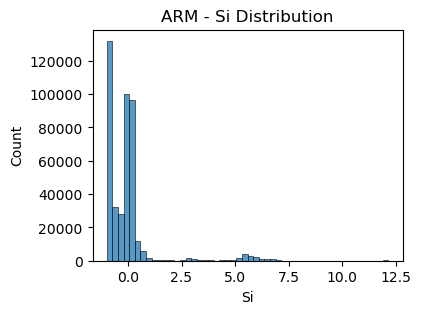

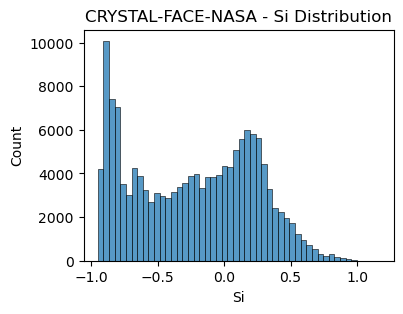

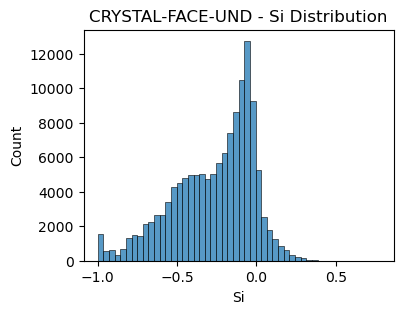

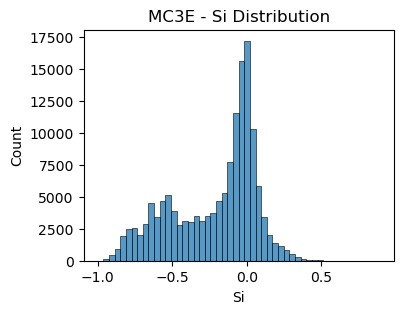

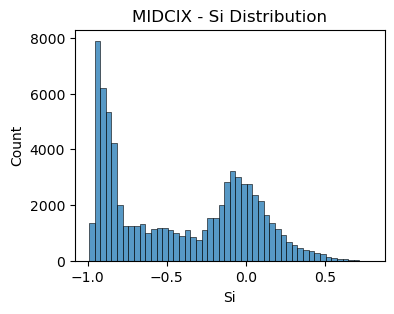

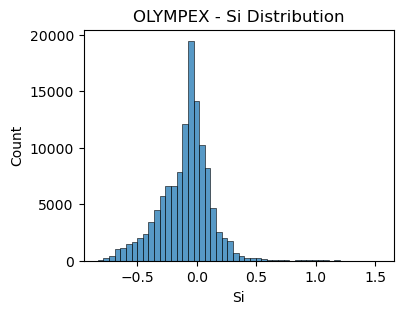

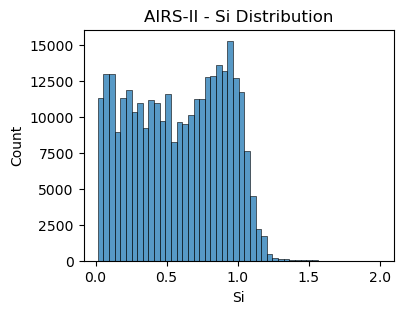

=== ARM ===
['Date', 'Time(sec)', 'True Air Speed (m/s)', 'Wind Speed (m/s)', 'Wind Direction (deg)', 'INS Heading (deg)', 'Pitch (deg)', 'Roll (deg)', 'Static Pressure (mb)', 'Pressure Altitude (m)', 'Air Temp Rosemount (C)', 'Dew Point EG&G (C)', 'Dew Point Cryo (C)', 'Frost Point Cryo (C)', 'King LWC (g/m3)', 'FSSP LWC (g/m3)', 'Vertical Wind (m/s)', 'Turbulence (eps^(1/3))', 'Ozone (ppb)', 'CN Conc (#/cm3)', 'INS Latitude (deg)', 'INS Longitude (deg)', 'GPS Lat (deg)', 'GPS Lon (deg)', 'GPS Alt (m)', 'GPS Ground Speed (m/s)', 'FSSP Conc (#/ml)', 'FSSP Mean Diam (µm)', 'FSSP Mean Vol Diam (µm)', '1DC Conc (#/L)', '1DC Mean Diam (µm)', '1DC Mean Vol Diam (µm)', '2DC Conc (#/L)', '2DC Mean Diam (µm)', '2DC Mean Vol Diam (µm)', '2DC Shadow-Or (#/L)', '2DP Conc (#/L)', '2DP Mean Diam (µm)', '2DP Mean Vol Diam (µm)', 'Timestamp', 'Si', 'Campaign', 'source_file']
=== CRYSTAL-FACE-NASA ===
['UT_s', 'ppmv', 'P_mb', 'T_K', 'Ep_mb', 'Td_C', 'Esh_mb', 'Esi_mb', 'RH', 'g_kg', 'Timestamp', 'Si',

In [14]:
# Map campaign to air temperature column name
AIR_TEMP_COLS = {
    "ARM": "Air Temp Rosemount (C)",
    "CRYSTAL-FACE-NASA": "T_C",  # Update this if your NASA files use a different name
    "CRYSTAL-FACE-UND": "Tair",   # Update as needed
    "MC3E": "Air_Temp",
    "MIDCIX": "T_C",             # Update as needed
    "OLYMPEX": "Air_Temp",
    "AIRS-II": "ATX".
    "ATTREX": "T"
}

def extract_final_df(df, campaign):
    # Try to find a timestamp column
    if "Timestamp" in df.columns:
        ts = pd.to_datetime(df["Timestamp"], errors="coerce", utc=True)
    elif "Date" in df.columns and "Time(sec)" in df.columns:
        ts = pd.to_datetime(df["Date"], errors="coerce") + pd.to_timedelta(df["Time(sec)"], unit="s")
        ts = ts.dt.tz_localize("UTC")
    else:
        # Try to find any datetime column
        ts = pd.to_datetime(df.iloc[:, 0], errors="coerce", utc=True)
    # Find air temperature column
    tair_col = AIR_TEMP_COLS.get(campaign)
    if tair_col not in df.columns:
        # Try to find a column containing 'temp' (case-insensitive)
        tair_candidates = [c for c in df.columns if "temp" in c.lower()]
        tair_col = tair_candidates[0] if tair_candidates else df.columns[1]
    tair = df[tair_col]
    # Build final DataFrame
    out = pd.DataFrame({
        "Timestamp": ts.dt.tz_convert("UTC") if ts.dt.tz else ts,
        "Tair": tair,
        "Si": df["Si"]
    })
    return out.dropna(subset=["Timestamp", "Tair", "Si"])

# Load all campaigns
all_data = {name: load_campaign(name) for name in CAMPAIGNS}

# Quick visualization
for name, df in all_data.items():
    si = df["Si"].dropna()
    plt.figure(figsize=(4,3))
    sns.histplot(si, bins=50)
    plt.title(f"{name} - Si Distribution")
    plt.xlabel("Si")
    plt.show()

final_dfs = []
for name, df in all_data.items():
    print(f'=== {name} ===')
    print(df.columns.tolist())
    temp_df = extract_final_df(df, name)
    temp_df["Campaign"] = name
    final_dfs.append(temp_df)
df_final = pd.concat(final_dfs, ignore_index=True)

# Only keep the four columns
df_final = df_final[["Timestamp", "Tair", "Si", "Campaign"]]
print(df_final.head())

In [16]:
df_final.head()

,Timestamp,Tair,Si,Campaign
0,2000-03-12 22:22:05+00:00,15.018,-0.322695,ARM
1,2000-03-12 22:22:05.250000+00:00,15.028,-0.323351,ARM
2,2000-03-12 22:22:05.500000+00:00,15.028,-0.316420,ARM
3,2000-03-12 22:22:05.750000+00:00,15.031,-0.313372,ARM
4,2000-03-12 22:22:06+00:00,15.025,-0.313173,ARM


In [17]:
df_final.shape

(1367277, 4)

In [9]:
# Count rows with any missing value in Timestamp, Tair, or Si
missing_count = df_final[["Timestamp", "Tair", "Si"]].isnull().any(axis=1).sum()
print(f"Number of records with missing data: {missing_count}")

Number of records with missing data: 0


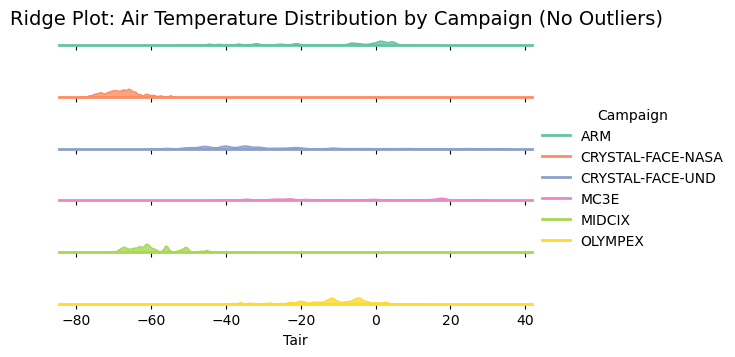

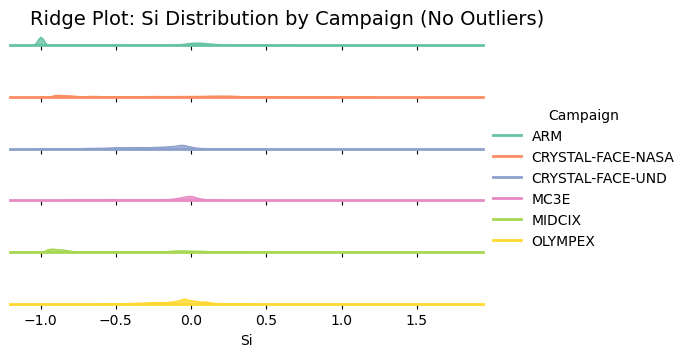

In [10]:
def remove_outliers(df, col):
    def iqr_filter(group):
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        mask = (group[col] >= q1 - 1.5 * iqr) & (group[col] <= q3 + 1.5 * iqr)
        return group.loc[mask]
    # Select all columns after groupby to avoid the warning
    return df.groupby("Campaign", group_keys=False)[df.columns].apply(iqr_filter)

df_tair_no_outliers = remove_outliers(df_final, "Tair")
df_si_no_outliers = remove_outliers(df_final, "Si")

# Ridge plot for Tair (no outliers)
pal = sns.color_palette("Set2", n_colors=df_tair_no_outliers["Campaign"].nunique())
g = sns.FacetGrid(
    df_tair_no_outliers, 
    row="Campaign", 
    hue="Campaign", 
    aspect=10, 
    height=0.6, 
    palette=pal
)
g.map(sns.kdeplot, "Tair", bw_adjust=0.5, fill=True, alpha=0.8)
g.map(plt.axhline, y=0, lw=2, clip_on=False)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.subplots_adjust(left=0.15)
plt.suptitle("Ridge Plot: Air Temperature Distribution by Campaign (No Outliers)", fontsize=14)
g.add_legend(title="Campaign")
plt.show()

# Ridge plot for Si (no outliers)
pal = sns.color_palette("Set2", n_colors=df_si_no_outliers["Campaign"].nunique())
g = sns.FacetGrid(
    df_si_no_outliers, 
    row="Campaign", 
    hue="Campaign", 
    aspect=10, 
    height=0.6, 
    palette=pal
)
g.map(sns.kdeplot, "Si", bw_adjust=0.5, fill=True, alpha=0.8)
g.map(plt.axhline, y=0, lw=2, clip_on=False)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.subplots_adjust(left=0.15)
plt.suptitle("Ridge Plot: Si Distribution by Campaign (No Outliers)", fontsize=14)
g.add_legend(title="Campaign")
plt.show()

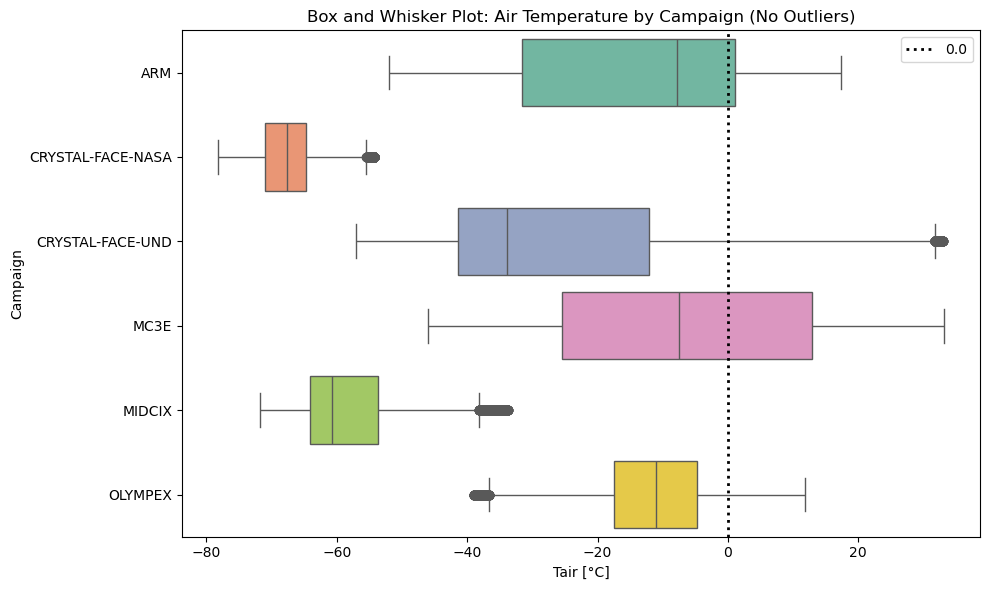

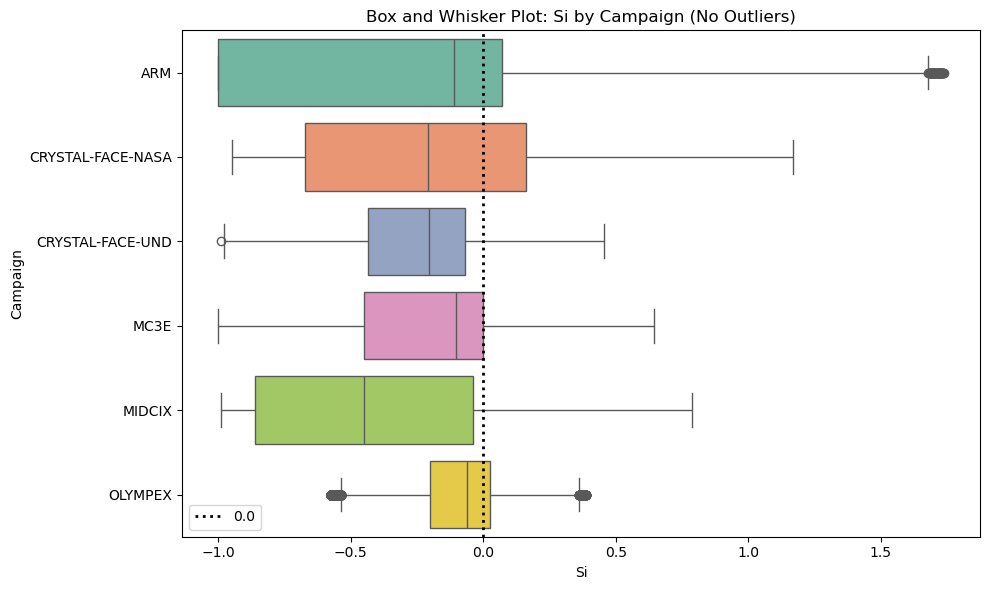

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot for Tair (no outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_tair_no_outliers,
    x="Tair",
    y="Campaign",
    hue="Campaign",
    palette="Set2",
    orient="h",
    dodge=False,
    legend=False
)
plt.axvline(0.0, color='k', linestyle=':', linewidth=2, label='0.0')
plt.title("Box and Whisker Plot: Air Temperature by Campaign (No Outliers)")
plt.xlabel("Tair [°C]")
plt.ylabel("Campaign")
plt.legend()
plt.tight_layout()
plt.show()

# Box plot for Si (no outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_si_no_outliers,
    x="Si",
    y="Campaign",
    hue="Campaign",
    palette="Set2",
    orient="h",
    dodge=False,
    legend=False
)
plt.axvline(0.0, color='k', linestyle=':', linewidth=2, label='0.0')
plt.title("Box and Whisker Plot: Si by Campaign (No Outliers)")
plt.xlabel("Si")
plt.ylabel("Campaign")
plt.legend()
plt.tight_layout()
plt.show()

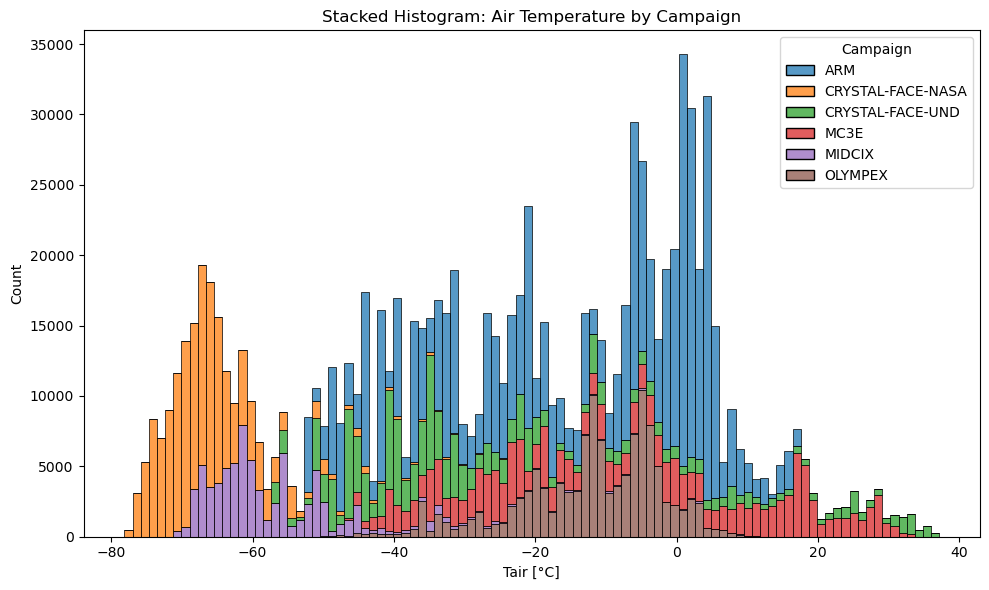

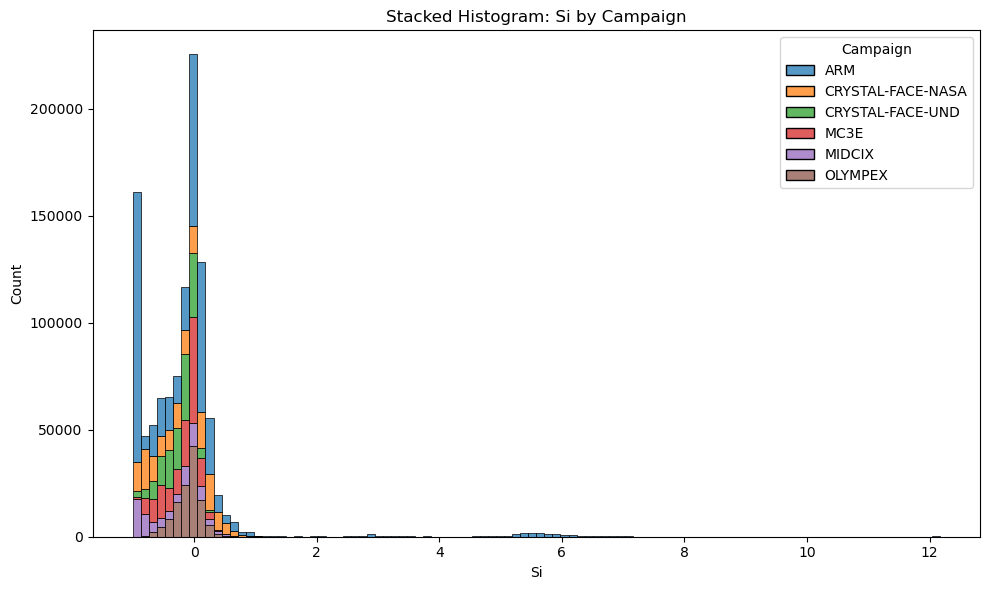

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_final, x="Tair", hue="Campaign", multiple="stack", bins=100)
plt.title("Stacked Histogram: Air Temperature by Campaign")
plt.xlabel("Tair [°C]")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(data=df_final, x="Si", hue="Campaign", multiple="stack", bins=100)
plt.title("Stacked Histogram: Si by Campaign")
plt.xlabel("Si")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
# Data time frame from COCPIT data
summary

,Earliest,Latest,Duration,Campaign_Length
Campaign,,,,
ARM,2000-03-09 18:57:35,2000-03-19 15:45:03,9 days 20:47:28,9d 20h 47m 28s
CRYSTAL_FACE_NASA,2002-07-09 15:34:18,2002-07-29 20:12:55,20 days 04:38:37,20d 4h 38m 37s
CRYSTAL_FACE_UND,2002-07-03 17:30:06,2002-07-29 20:50:15,26 days 03:20:09,26d 3h 20m 9s
MC3E,2011-05-23 16:35:05,2011-06-02 12:26:08,9 days 19:51:03,9d 19h 51m 3s
MIDCIX,2004-04-19 17:03:29,2004-05-06 20:36:07,17 days 03:32:38,17d 3h 32m 38s
MPACE,2004-09-30 01:01:20,2004-10-21 23:57:15,21 days 22:55:55,21d 22h 55m 55s


In [14]:
# Check time frame from processed in situ data 
def format_duration(td):
    days = td.days
    seconds = td.seconds
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{days}d {hours}h {minutes}m {secs}s"

# Ensure Timestamp is datetime
df_final["Timestamp"] = pd.to_datetime(df_final["Timestamp"])

# Group by Campaign and calculate earliest, latest, and duration
summary_2 = (
    df_final.groupby("Campaign")["Timestamp"]
    .agg(Earliest="min", Latest="max")
    .reset_index()
)

summary_2["Duration"] = summary_2["Latest"] - summary_2["Earliest"]
summary_2["Campaign_Length"] = summary_2["Duration"].apply(format_duration)

# Set Campaign as index for display
summary_2 = summary_2.set_index("Campaign")
summary_2

,Earliest,Latest,Duration,Campaign_Length
Campaign,,,,
ARM,2000-03-09 18:31:10+00:00,2000-03-19 18:54:58.750000+00:00,10 days 00:23:48.750000,10d 0h 23m 48s
CRYSTAL-FACE-NASA,2002-06-27 14:45:14+00:00,2002-07-28 23:15:03+00:00,31 days 08:29:49,31d 8h 29m 49s
CRYSTAL-FACE-UND,2002-07-03 17:14:25+00:00,2002-07-29 21:24:17+00:00,26 days 04:09:52,26d 4h 9m 52s
MC3E,2011-04-22 21:49:38.040000+00:00,2011-06-02 18:19:35.990000+00:00,40 days 20:29:57.950000,40d 20h 29m 57s
MIDCIX,2004-04-17 15:21:28.900000+00:00,2004-05-06 20:10:11.600000+00:00,19 days 04:48:42.700000,19d 4h 48m 42s
OLYMPEX,2015-11-18 21:29:39.035000+00:00,2015-12-19 03:59:55.445000+00:00,30 days 06:30:16.410000,30d 6h 30m 16s


In [16]:
df_final.columns

Index(['Timestamp', 'Tair', 'Si', 'Campaign'], dtype='object')

In [18]:
df_final['Timestamp'].head()

0          2000-03-12 22:22:05+00:00
1   2000-03-12 22:22:05.250000+00:00
2   2000-03-12 22:22:05.500000+00:00
3   2000-03-12 22:22:05.750000+00:00
4          2000-03-12 22:22:06+00:00
Name: Timestamp, dtype: datetime64[ns, UTC]

In [17]:
# Percent of missing Timestamps per Campaign
missing_percent = (
    df_final
    .groupby("Campaign")["Timestamp"]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index(name="percent_missing")
)

print(missing_percent)

            Campaign  percent_missing
0                ARM              0.0
1  CRYSTAL-FACE-NASA              0.0
2   CRYSTAL-FACE-UND              0.0
3               MC3E              0.0
4             MIDCIX              0.0
5            OLYMPEX              0.0


In [15]:
# save combined env data 
save_filename = 'combined_env_si_airtemp_01.parquet'
save_path = os.path.join('../data/env', save_filename)
df_final.to_parquet(save_path, index=False)